# EDA - BybitML historical dataset

Exploratory data analysis of data/raw/bybit_ec_all14days_Tx.parquet: 14-day window of ERC transactions (2025-02-21 - 2025-03-07), investigating the money laundering trail following the ByBit hack.

The dataset originates from: https://osf.io/nx7aj/files/sv92h?view_only=663038fbea43491bb4010011c7f28b23
and was constructed / labeled by the authors of the paper: https://arxiv.org/abs/2608.17355

In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [43]:
sns.set_theme(
    style="whitegrid",
    rc={"figure.figsize": (8,4), "figure.dpi": 150},
)

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path().cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bybit_ec_all14days_Tx.parquet"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load data and first look

In [44]:
df = pd.read_parquet(DATA_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2616736 entries, 0 to 2616735
Data columns (total 19 columns):
 #   Column           Dtype  
---  ------           -----  
 0   hash             str    
 1   from             str    
 2   to               str    
 3   value            float64
 4   timeStamp        int64  
 5   blockNumber      float64
 6   tokenName        str    
 7   tokenSymbol      str    
 8   tokenDecimal     int64  
 9   contractAddress  str    
 10  isError          float64
 11  gasPrice         float64
 12  gasUsed          float64
 13  gasLimit         float64
 14  gasFee           float64
 15  tx_label         int64  
 16  from_label       float64
 17  to_label         float64
 18  index            int64  
dtypes: float64(9), int64(4), str(6)
memory usage: 855.9 MB


In [45]:
df.head()

,hash,from,to,value,timeStamp,blockNumber,tokenName,tokenSymbol,tokenDecimal,contractAddress,isError,gasPrice,gasUsed,gasLimit,gasFee,tx_label,from_label,to_label,index
0,0x00008e3d6b4102407a7521d2dd4a867193d20d650488...,0x0000000000000000000000000000000000000000,0x7d128742816aa09af2e9f0ca8c96450ceec17d7a,5000.000000,1740162227,21896482.0,SY Mellow ENA,SY-rsENA,18,0x64046776c9c856fdc5c39c6eba101adc8e18291f,0.0,3.893286e+09,320707.0,456883.0,1.248604e-03,0,NaN,NaN,102122
1,0x00008e3d6b4102407a7521d2dd4a867193d20d650488...,0x0000000000000000000000000000000000000000,0x7e0209ab6fa3c7730603b68799bbe9327dab7e88,107599.960938,1740162227,21896482.0,PT Mellow ENA 27MAR2025,PT-rsENA-27MAR2025,18,0xb930dd4ea22cd4404c30d68b72e18453adcf93a2,0.0,3.893286e+09,320707.0,456883.0,1.248604e-03,0,NaN,NaN,102150
2,0x0002050acc869b6a7b6ccc85a3d911d7e1ff08e22cad...,0x111111125421ca6dc452d289314280a0f8842a65,0xc7bbec68d12a0d1830360f8ec58fa599ba1b0e9b,0.080498,1740215711,21900912.0,Wrapped Ether,WETH,18,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,0.0,1.317080e+09,162517.0,264108.0,2.140479e-04,0,NaN,NaN,358190
3,0x0002050acc869b6a7b6ccc85a3d911d7e1ff08e22cad...,0x56bc8f3293f53825c9fbd6ddfe0cafefa82820d0,0x111111125421ca6dc452d289314280a0f8842a65,0.080498,1740215711,21900912.0,Wrapped Ether,WETH,18,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,0.0,1.317080e+09,162517.0,264108.0,2.140479e-04,0,NaN,NaN,358167
4,0x0003addb1327f4ece4c766f2387b1c4c0ad60bce3352...,0x000000000004444c5dc75cb358380d2e3de08a90,0x3416cf6c708da44db2624d63ea0aaef7113527c6,142329.781250,1740154691,21895858.0,Tether USD,USDT,6,0xdac17f958d2ee523a2206206994597c13d831ec7,0.0,2.080106e+02,1072090.0,1531557.0,2.230061e-10,0,NaN,NaN,54439


## Null/burn addresses: exclusion from graph topology

0x000...000 and 0x000...dead are ERC-20 protocol sentinels, not actual actors - minting/burning tokens emits Transfer(from=0x0, ...) or vice-versa. Including them in the graph creates false proximity between unrelated addresses (anyone who has ever minted the same token becomes a "neighbor").

We exclude these addresses from:
- edges used to calculate degree/hop-distance
- the address population for which we calculate features
However the sheer involvement in mint/burn operations is encoded as a standard behavioral feature for other addresses.

In [46]:
NULL_ADDRESSES = {
    "0x0000000000000000000000000000000000000000",
    "0x000000000000000000000000000000000000dead",
}

is_mint_or_burn = df["from"].isin(NULL_ADDRESSES) | df["to"].isin(NULL_ADDRESSES)
df_graph = df[~is_mint_or_burn].copy()
mint_burn_rows = df[is_mint_or_burn]
print(f"mint/burn rows: {len(mint_burn_rows)} ({len(mint_burn_rows) / len(df):.2%})")

mint/burn rows: 176102 (6.73%)


## tx_label - redundant lookup

In [47]:
df[["from_label", "to_label", "tx_label"]].value_counts(dropna=False)

from_label  to_label  tx_label
NaN         NaN       0           2417218
1.0         0.0       2            156411
            1.0       1             23336
0.0         1.0       2             19771
Name: count, dtype: int64

***
tx_label turns out to be a deterministic function of from_label and to_label - it carries no additional information beyond the address labels themselves. From this point forward in the notebook tx_label is no longer used. Further analysis relies exclusively on address labeling
***

## Address labels table
from_label/to_label are address labels, not transaction labels - the same address appears in multiple rows. We are building a single address - label mapping table

In [48]:
address_label_occurrences = pd.concat(
    [
        df[["from", "from_label"]].rename(columns={"from": "address", "from_label": "label"}),
        df[["to", "to_label"]].rename(columns={"to": "address", "to_label": "label"}),
    ],
    ignore_index=True,
)
label_counts = address_label_occurrences.groupby("address")["label"].nunique()
label_counts[label_counts > 1]

Series([], Name: label, dtype: int64)

Confirmed lack of inconsistencies in address labeling.

In [49]:
address_label_occurrences_na_incl = address_label_occurrences.drop_duplicates(subset="address").reset_index(drop=True)
label_table = address_label_occurrences_na_incl["label"].value_counts(dropna=False)
label_table

label
0.0    34062
NaN    12712
1.0    12016
Name: count, dtype: int64

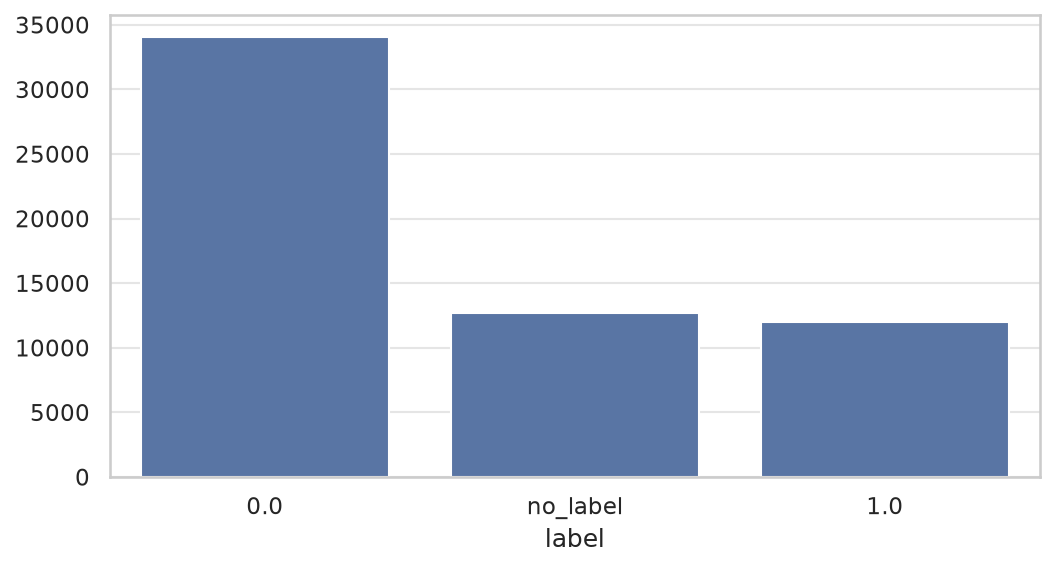

In [50]:
fig, ax = plt.subplots()
sns.barplot(x=label_table.index.fillna("no_label"), y=label_table.values, ax=ax)
plt.show()

In [51]:
address_label_occurrences = address_label_occurrences.dropna(subset=["label"])

unique_address_labels = address_label_occurrences.drop_duplicates("address").reset_index(drop=True)
# burn address drops out of the scored population
unique_address_labels = unique_address_labels[
    ~unique_address_labels["address"].isin(NULL_ADDRESSES)
].reset_index(drop=True)
print(f"unique labeled addresses: {len(unique_address_labels)}")

unique labeled addresses: 46231


## from_label / to_label: label sparsity in transactions

In [52]:
for col in ["from_label", "to_label"]:
    missing_rate = df[col].isna().mean()
    print(f"{col}: missing rate = {missing_rate:.2%}")
    print(df[col].value_counts(dropna=False))

from_label: missing rate = 92.38%
from_label
NaN    2417218
1.0     179747
0.0      19771
Name: count, dtype: int64
to_label: missing rate = 92.38%
to_label
NaN    2417218
0.0     156411
1.0      43107
Name: count, dtype: int64


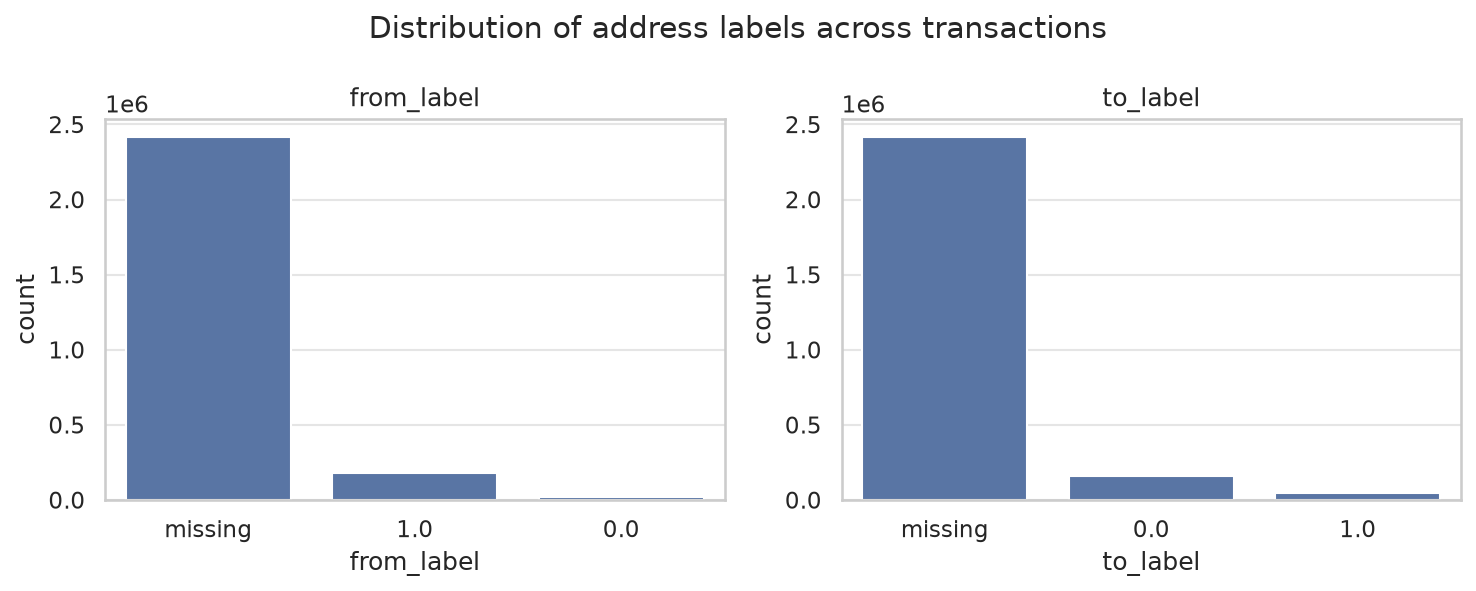

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["from_label", "to_label"]):
    counts = df[col].value_counts(dropna=False)
    counts.index = counts.index.map(lambda v: "missing" if pd.isna(v) else str(v))
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("count")
fig.suptitle("Distribution of address labels across transactions")
plt.tight_layout()
plt.show()

***
A stark discrepancy exists between the robust label coverage at the unique address level and the overwhelming prevalence of missing labels across the total transaction volume. This severe asymmetry indicates that the vast majority of network traffic is generated by a small subset of highly active, unclassified nodes. Such a distribution strongly supports the hypothesis that high-frequency infrastructure components, like smart contracts and routing pools, were deliberately left unlabeled. This methodological omission effectively prevents the distinct behavioral and topological signatures of standard EOA wallets from being polluted by automated institutional noise.
***

## Distribution of value (heavily right-skewed data)

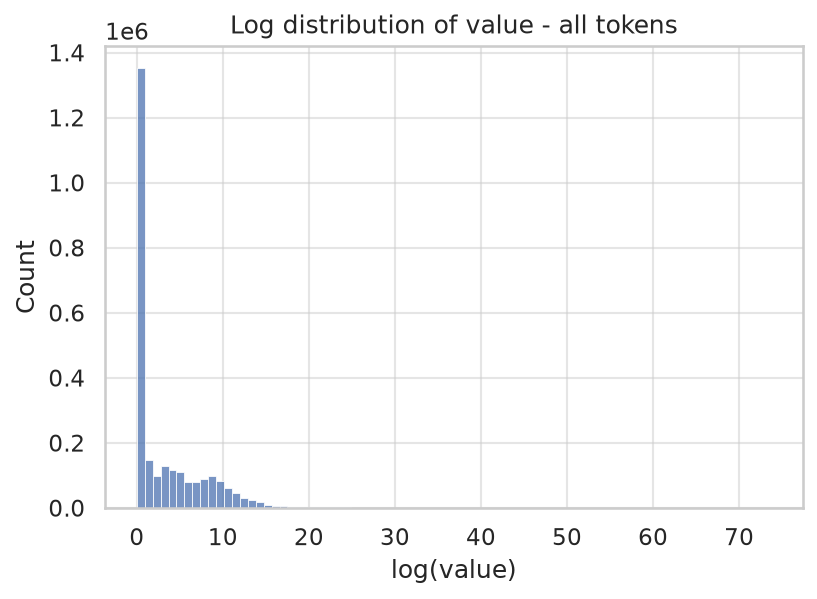

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(np.log1p(df["value"]), bins=80, ax=ax)
ax.set_xlabel("log(value)")
ax.set_title("Log distribution of value - all tokens")
plt.show()

***
This is a consequence of severe magnitude discrepancies in the values transmitted by different types of tokens.
***

Since token symbols/names can't be reserved by one subject/contract, we group by (contractAddress, tokenSymbol). Grouping by symbol alone would conflate legitimate and potentially malicious contracts under the same label.

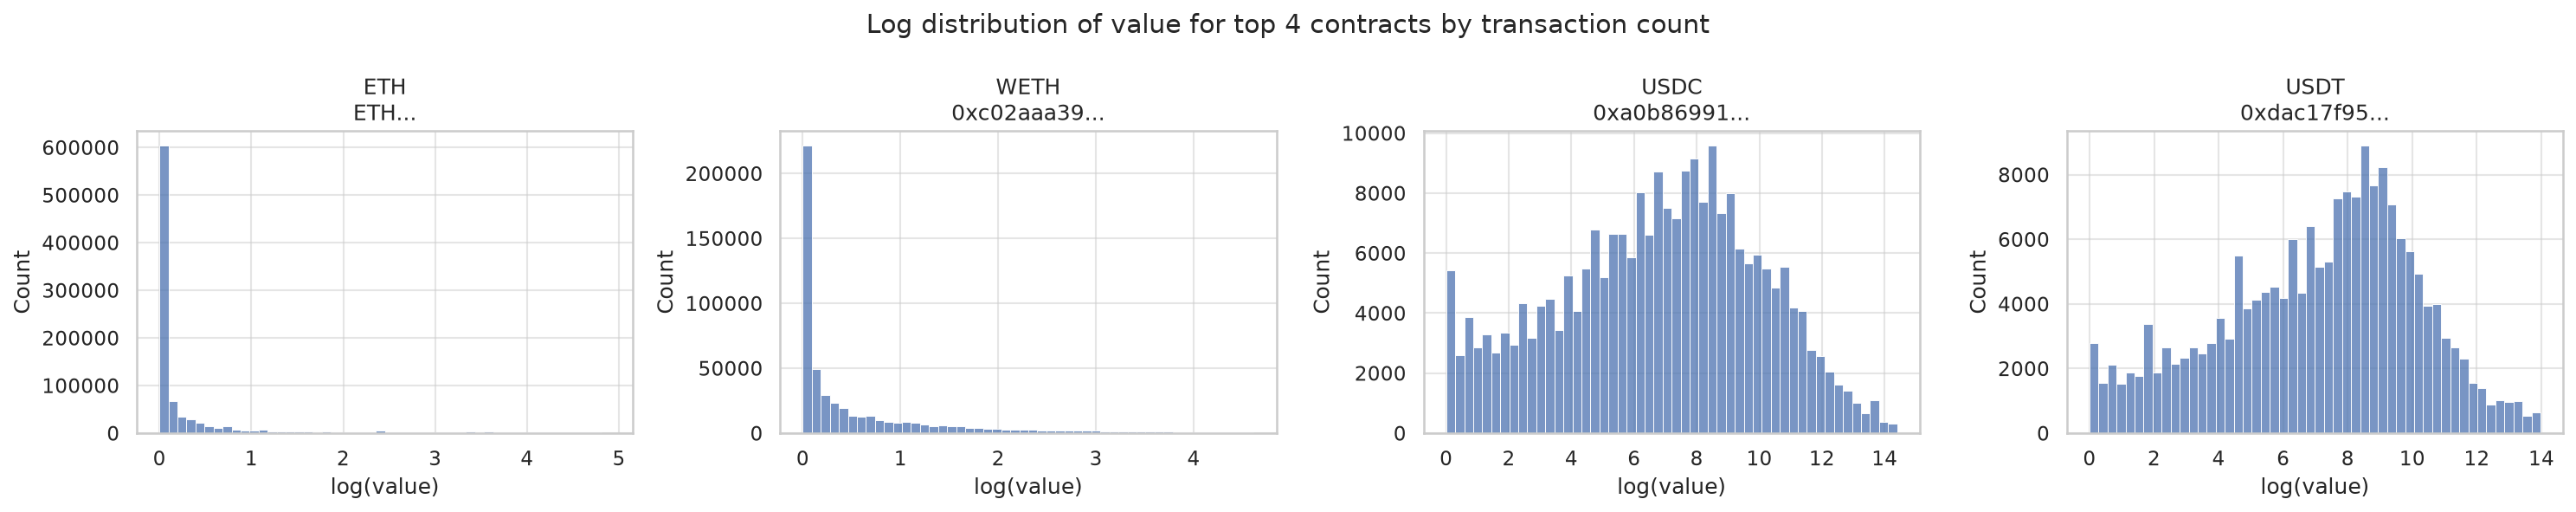

In [55]:
top5_by_count = df.groupby(["contractAddress", "tokenSymbol"]).size().sort_values(ascending=False).head(5)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (contract, symbol) in zip(axes, top5_by_count.index):
    subset = df.loc[df["contractAddress"] == contract, "value"]
    low, high = np.percentile(subset, [0.05, 99])
    sns.histplot(np.log1p(subset[(subset >= low) & (subset <= high)]), bins=50, ax=ax)
    ax.set_title(f"{symbol}\n{contract[:10]}...")
    ax.set_xlabel("log(value)")
fig.suptitle("Log distribution of value for top 4 contracts by transaction count")
plt.tight_layout()
plt.show()

***
The value distributions for stablecoins (USDC, USDT) exhibit a roughly log-normal shape, reflecting a broad spectrum of standard market transfers. Native and wrapped assets (ETH, WETH) on the other hand, are overwhelmingly dominated by near-zero value transactions. This is a signature typical of technical smart contract calls and network gas routing rather than actual value transfer.
***

## Gas distributions

Gas is an attribute of the transaction, not a single transfer - it is duplicated on every row sharing the same hash.
We deduplicate by hash before computing the distribution to prevent transactions with multiple transfers from being overrepreseted

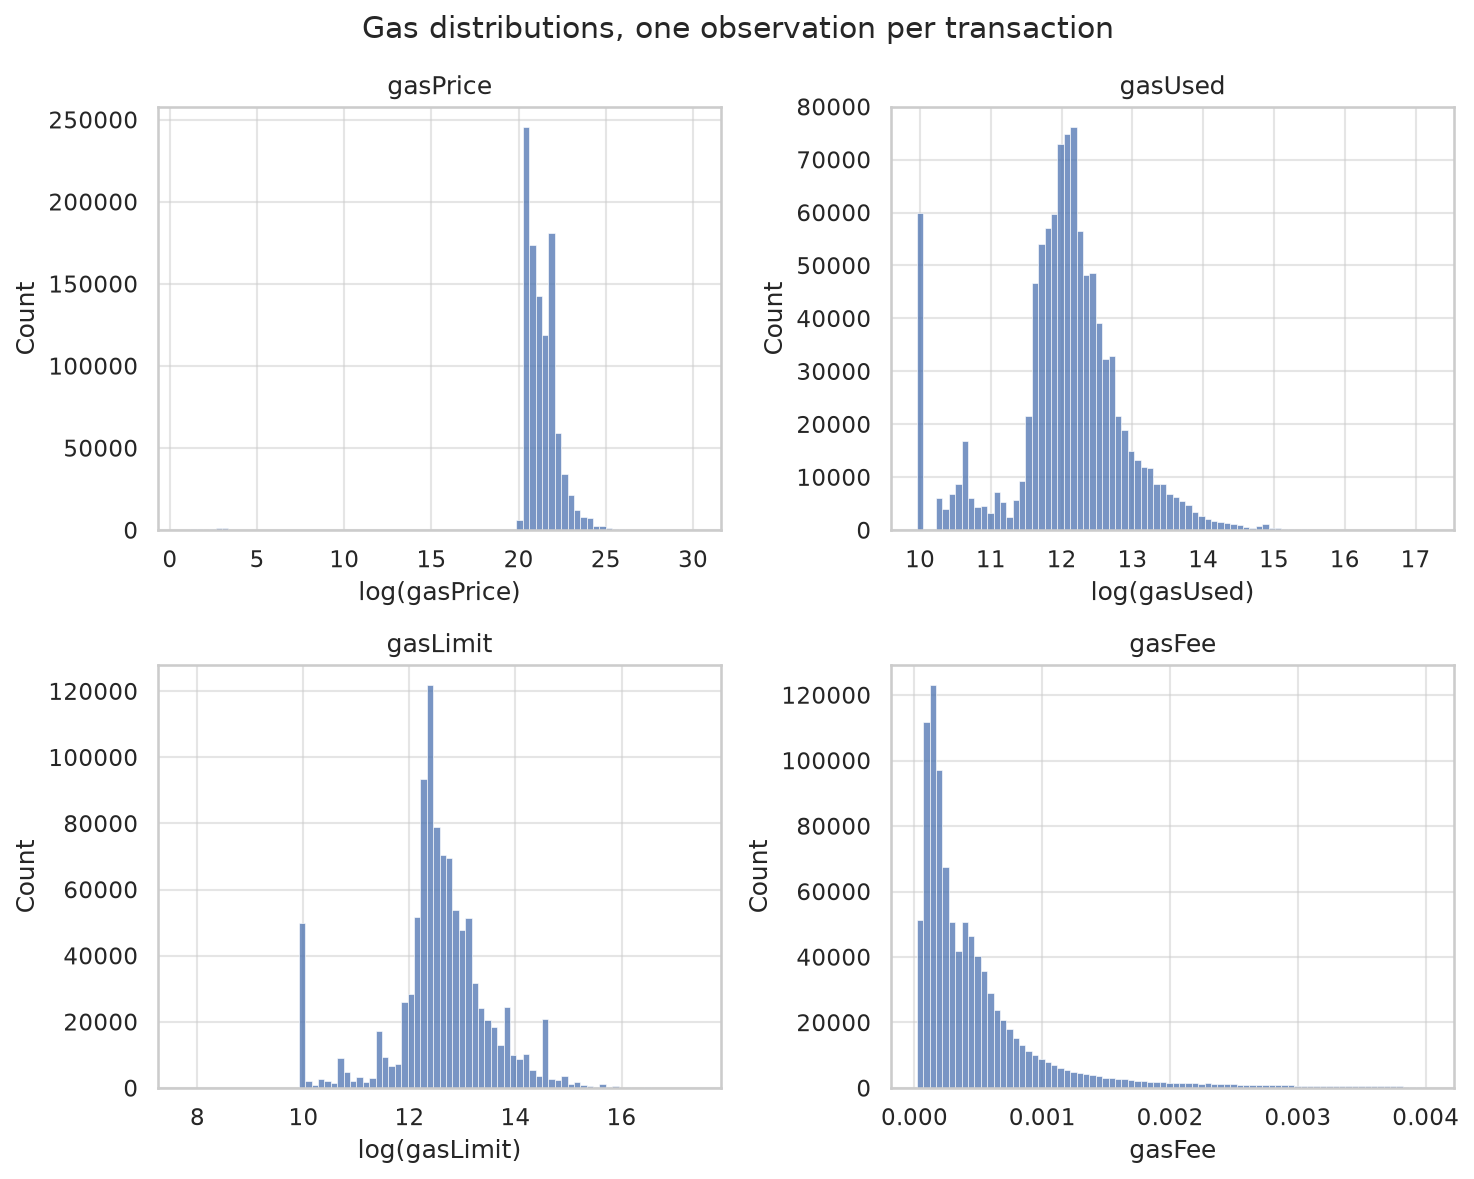

In [56]:
df_tx_level = df.drop_duplicates(subset="hash")

gas_cols = ["gasPrice", "gasUsed", "gasLimit", "gasFee"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, gas_cols):
    values = df_tx_level[col].dropna()
    values = values[values > 0]
    if col != "gasFee":
        sns.histplot(np.log1p(values), bins=80, ax=ax)
        ax.set_xlabel(f"log({col})")
    else:
        low, high = np.percentile(values, [2.5, 97.5])
        values = values[(values >= low) & (values <= high)]
        sns.histplot(values, bins=80, ax=ax)
        ax.set_xlabel(f"{col}")
    ax.set_title(col)
fig.suptitle("Gas distributions, one observation per transaction")
plt.tight_layout()
plt.show()

***

***

## Temporal distribution within the 14-day window

In [57]:
timestamps = pd.to_datetime(df["timeStamp"], unit="s")
print(f"window: {timestamps.min()} - {timestamps.max()}")

window: 2025-02-21 14:16:11 - 2025-03-07 14:12:23


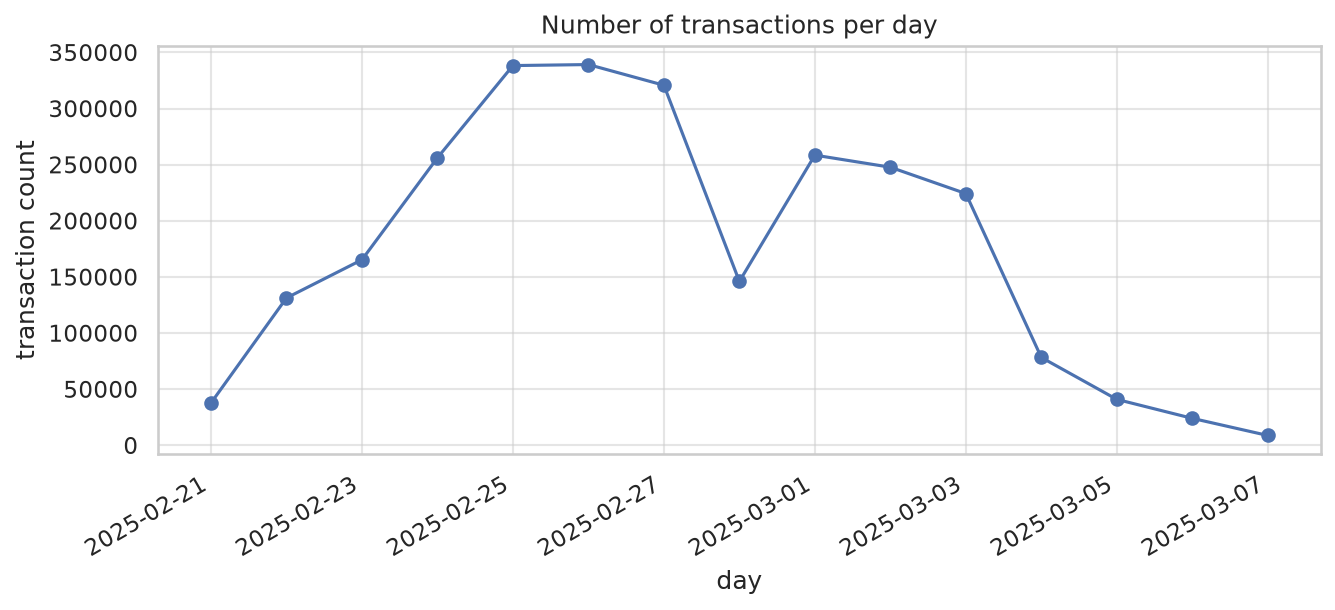

In [58]:
tx_by_day = timestamps.dt.floor("D").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tx_by_day.index, tx_by_day.values, marker="o")
ax.set_xlabel("day")
ax.set_ylabel("transaction count")
ax.set_title("Number of transactions per day")
fig.autofmt_xdate()
plt.show()

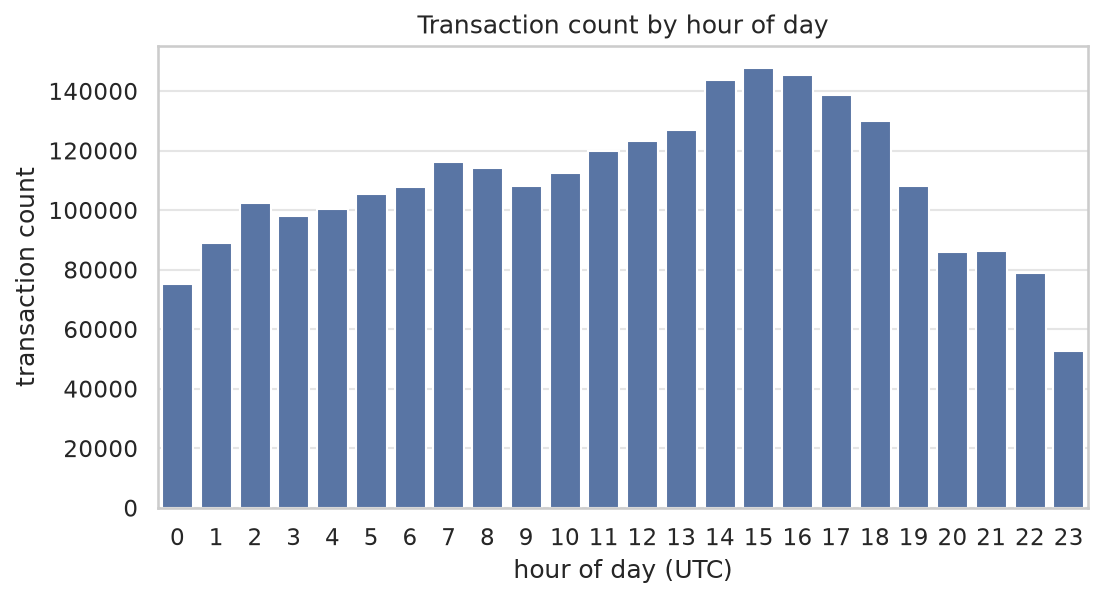

In [59]:
tx_by_hour = timestamps.dt.hour.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=tx_by_hour.index, y=tx_by_hour.values, ax=ax)
ax.set_xlabel("hour of day (UTC)")
ax.set_ylabel("transaction count")
ax.set_title("Transaction count by hour of day")
plt.show()

***
The daily time series reveals a distinct, isolated wave of activity that surges rapidly in the initial days of the observation window, peaking around February 25-27 (Tue-Thu) before systematically dying down. This transient dynamic strongly suggests the capture of a specific, localized market event or a coordinated operation, after which traffic within the observed sub-graph subsides. Conversely, the hourly breakdown displays a classic, smooth diurnal profile with a peak in the early afternoon, indicating that despite the incidental nature of the broader wave, the underlying operations still adhere to standard market rhythms or align with the working hours of a specific geographic timezone
***

## Top tokens by transaction count and volume

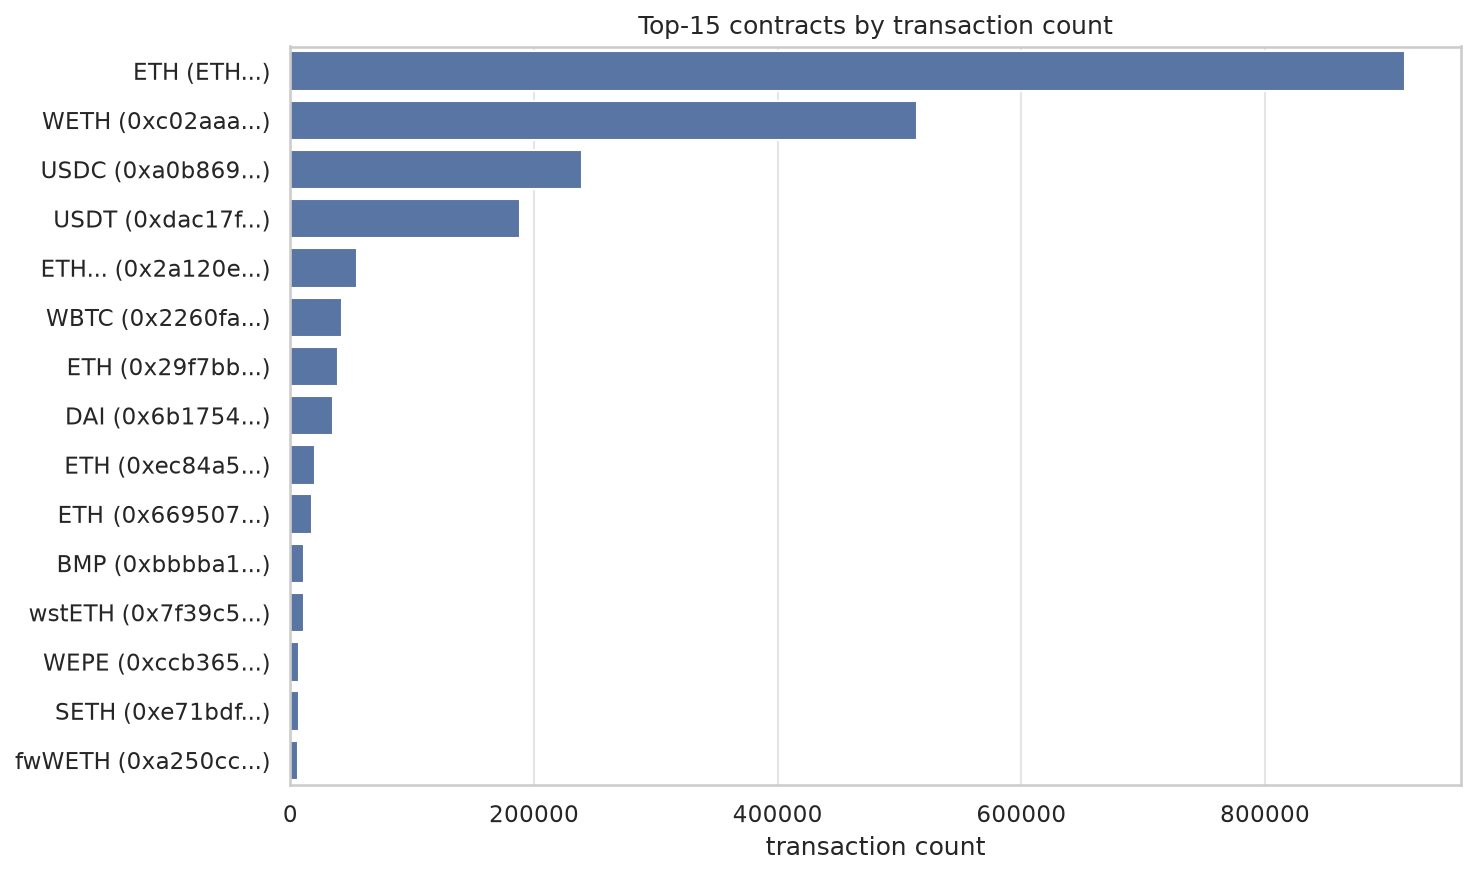

In [60]:
top15_by_count = (
    df.groupby(["contractAddress", "tokenSymbol"]).size().sort_values(ascending=False).head(15)
)
labels = [f"{symbol} ({contract[:8]}...)" for contract, symbol in top15_by_count.index]
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top15_by_count.values, y=labels, ax=ax, orient="h")
ax.set_xlabel("transaction count")
ax.set_title("Top-15 contracts by transaction count")
plt.tight_layout()
plt.show()

## Network statistics: address degrees

The thickness of the degree distribution tail is critical for the upcoming TGN architecture - hub addresses (like exchange hot wallets, mixers) will dominate the graph topology.
Calculated on df_graph (excluding mint/burn rows) - otherwise, the degree would be artificially inflated by interactions with protocol sentinels rather than real counterparties.

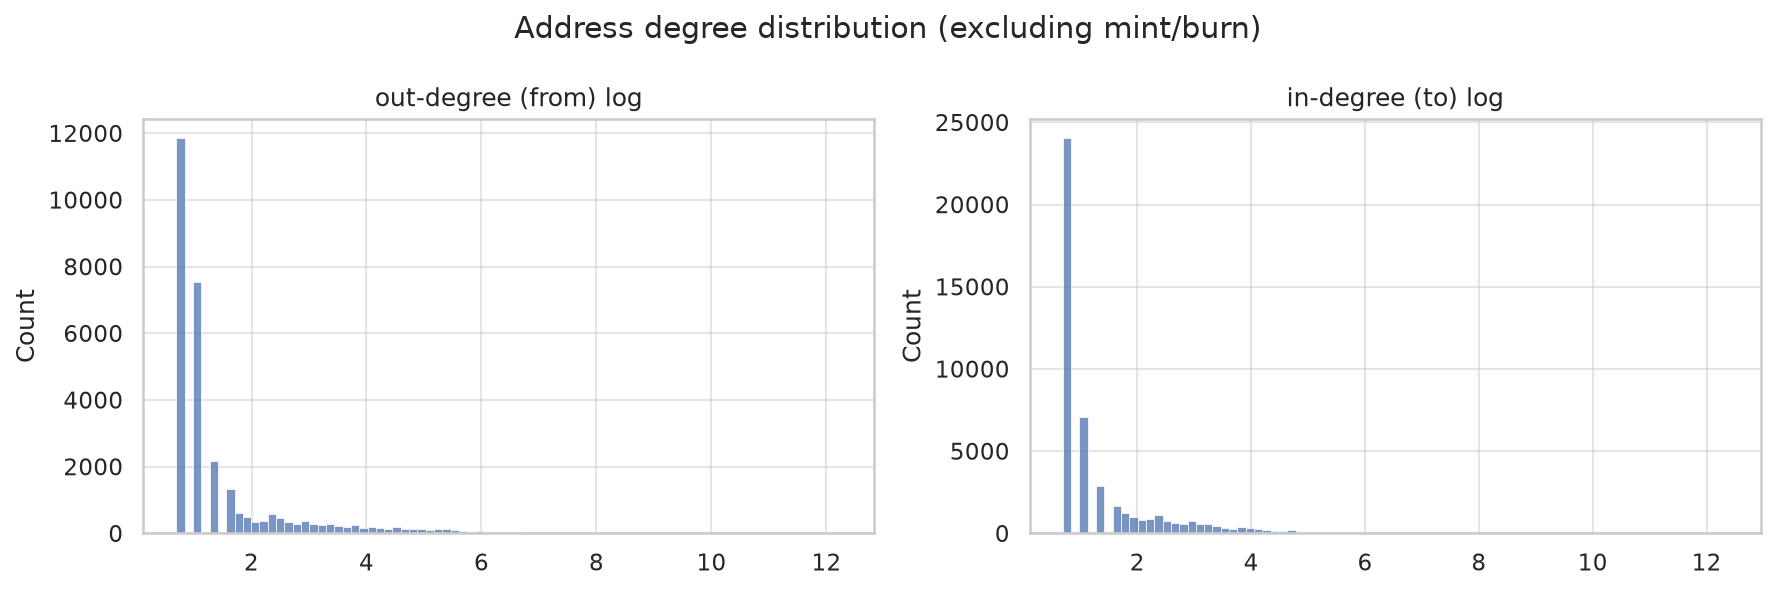

In [61]:
out_degree = df_graph["from"].value_counts()
in_degree = df_graph["to"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log1p(out_degree.values), bins=80, ax=axes[0])
axes[0].set_title("out-degree (from) log")
sns.histplot(np.log1p(in_degree.values), bins=80, ax=axes[1])
axes[1].set_title("in-degree (to) log")
fig.suptitle("Address degree distribution (excluding mint/burn)")
plt.tight_layout()
plt.show()

In [62]:
both_roles = set(df_graph["from"]) & set(df_graph["to"])
print(f"unique from: {df_graph['from'].nunique()}, unique to: {df_graph['to'].nunique()}")
print(f"addresses appearing in both roles: {len(both_roles)}")

unique from: 30490, unique to: 48227
addresses appearing in both roles: 21310


In [63]:
top10_out_degree = out_degree.head(10).rename_axis("address").reset_index(name="out_degree")
top10_out_degree = top10_out_degree.merge(unique_address_labels, on="address", how="left")
top10_out_degree

,address,out_degree,label
0,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,210554,0.0
1,0x66a9893cc07d91d95644aedd05d03f95e1dba8af,203385,0.0
2,0x5141b82f5ffda4c6fe1e372978f1c5427640a190,134354,0.0
3,0x0d0e364aa7852291883c162b22d6d81f6355428f,98102,NaN
4,0x74de5d4fcbf63e00296fd95d33236b9794016631,64548,0.0
5,0xa69babef1ca67a37ffaf7a485dfff3382056e78c,57998,NaN
6,0xc7bbec68d12a0d1830360f8ec58fa599ba1b0e9b,43769,0.0
7,0x9008d19f58aabd9ed0d60971565aa8510560ab41,43454,0.0
8,0xe0554a476a092703abdb3ef35c80e0d76d32939f,42643,0.0
9,0x1231deb6f5749ef6ce6943a275a1d3e7486f4eae,42414,0.0


## Address features (per address)

We aggregate transactional features per unique labeled address - serving as a starting point to investigate what actually differentiates confirmed fraud (label= from confirmed clean neighbor.

Features calculated on df_graph (without mint/burn) - mint/burn involvement is returned separately as an explicit behavioral feature rather than being smeared across degree/value/activity metrics.

Gas deduplicated by (address, hash) before averaging - otherwise, a transaction with many transfers would overrepresent its gas in the address's average.

tokens_sent/tokens_received grouped by contractAddress, not tokenSymbol - for the same reason as in the top tokens section.

value is normalized using the z-score of log(value) computed SEPARATELY per contractAddress - ETH vs memecoins vs spoofed tokens are not economically comparable without price data, which we lack for most of the contracts. A self-referential approach is robust to drift: recalculated from scratch on every batch, not fitted once on old data and blindly applied to fresh data. Grouping by contractAddress inherently isolates spoofed tokens into their own reference frame. Contracts with <2 observations (std=0/NaN) receive a z-score=0.

In [64]:
df_graph["log_value"] = np.log1p(df_graph["value"])
token_value_mean = df_graph.groupby("contractAddress")["log_value"].transform("mean")
token_value_std = df_graph.groupby("contractAddress")["log_value"].transform("std")
df_graph["value_zscore"] = np.where(
    token_value_std > 0, (df_graph["log_value"] - token_value_mean) / token_value_std, 0.0
)
df_graph[:5]

,hash,from,to,value,timeStamp,blockNumber,tokenName,tokenSymbol,tokenDecimal,contractAddress,...,gasPrice,gasUsed,gasLimit,gasFee,tx_label,from_label,to_label,index,log_value,value_zscore
2,0x0002050acc869b6a7b6ccc85a3d911d7e1ff08e22cad...,0x111111125421ca6dc452d289314280a0f8842a65,0xc7bbec68d12a0d1830360f8ec58fa599ba1b0e9b,0.080498,1740215711,21900912.0,Wrapped Ether,WETH,18,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,...,1.317080e+09,162517.0,264108.0,2.140479e-04,0,NaN,NaN,358190,0.077422,-0.519179
3,0x0002050acc869b6a7b6ccc85a3d911d7e1ff08e22cad...,0x56bc8f3293f53825c9fbd6ddfe0cafefa82820d0,0x111111125421ca6dc452d289314280a0f8842a65,0.080498,1740215711,21900912.0,Wrapped Ether,WETH,18,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,...,1.317080e+09,162517.0,264108.0,2.140479e-04,0,NaN,NaN,358167,0.077422,-0.519179
4,0x0003addb1327f4ece4c766f2387b1c4c0ad60bce3352...,0x000000000004444c5dc75cb358380d2e3de08a90,0x3416cf6c708da44db2624d63ea0aaef7113527c6,142329.781250,1740154691,21895858.0,Tether USD,USDT,6,0xdac17f958d2ee523a2206206994597c13d831ec7,...,2.080106e+02,1072090.0,1531557.0,2.230061e-10,0,NaN,NaN,54439,11.865909,1.497051
5,0x0003addb1327f4ece4c766f2387b1c4c0ad60bce3352...,0x000000000004444c5dc75cb358380d2e3de08a90,0xb9a4406982d990648093c71eff9f1f63a040152e,142513.015625,1740154691,21895858.0,Tether USD,USDT,6,0xdac17f958d2ee523a2206206994597c13d831ec7,...,2.080106e+02,1072090.0,1531557.0,2.230061e-10,0,NaN,NaN,54400,11.867196,1.497458
6,0x0003addb1327f4ece4c766f2387b1c4c0ad60bce3352...,0x3416cf6c708da44db2624d63ea0aaef7113527c6,0x828ae1566824a9835acb6f565e1e9ea22bfb883a,71398.250000,1740154691,21895858.0,USD Coin,USDC,6,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,...,2.080106e+02,1072090.0,1531557.0,2.230061e-10,0,NaN,NaN,54448,11.176043,1.301101


In [65]:
sent = df_graph.rename(columns={"from": "address"})
received = df_graph.rename(columns={"to": "address"})

out_degree_feat = sent.groupby("address").size().rename("out_degree")
in_degree_feat = received.groupby("address").size().rename("in_degree")

value_sent = sent.groupby("address")["value_zscore"].agg(
    value_sent_zscore_mean="mean", value_sent_zscore_median="median"
)
value_received = received.groupby("address")["value_zscore"].agg(
    value_received_zscore_mean="mean", value_received_zscore_median="median"
)
value_received[:5]

,value_received_zscore_mean,value_received_zscore_median
address,,
0x00000000000000adc04c56bf30ac9d3c0aaf14dc,-0.414604,-0.414604
0x000000000000100921465982d28b37d2006e87fc,-0.474043,-0.456338
0x0000000000001ff3684f28c67538d4d072c22734,-0.230496,-0.402455
0x000000000000305b8621e2475aee38ab5721d525,-0.680659,-0.574473
0x0000000000007f150bd6f54c40a34d7c3d5e9f56,0.215619,0.215619


In [66]:
sent_tx_level = sent.drop_duplicates(subset=["address", "hash"])
gas_feat = sent_tx_level.groupby("address")[["gasPrice", "gasUsed", "gasFee"]].mean()
gas_feat = gas_feat.rename(
    columns={"gasPrice": "gas_price_mean", "gasUsed": "gas_used_mean", "gasFee": "gas_fee_mean"}
)

tokens_sent = sent.groupby("address")["contractAddress"].nunique().rename("tokens_sent")
tokens_received = received.groupby("address")["contractAddress"].nunique().rename("tokens_received")

tokens_received[:5]

address
0x00000000000000adc04c56bf30ac9d3c0aaf14dc    1
0x000000000000100921465982d28b37d2006e87fc    2
0x0000000000001ff3684f28c67538d4d072c22734    1
0x000000000000305b8621e2475aee38ab5721d525    3
0x0000000000007f150bd6f54c40a34d7c3d5e9f56    1
Name: tokens_received, dtype: int64

In [67]:
activity = pd.concat(
    [sent.groupby("address")["timeStamp"].agg(["min", "max"]),
     received.groupby("address")["timeStamp"].agg(["min", "max"])]
).groupby("address").agg({"min": "min", "max": "max"})
active_span_hours = ((activity["max"] - activity["min"]) / 3600).rename("active_span_hours")

active_span_hours[:5]

address
0x0000000000000068f116a894984e2db1123eb395      0.000000
0x00000000000000adc04c56bf30ac9d3c0aaf14dc      9.346667
0x000000000000100921465982d28b37d2006e87fc     66.876667
0x0000000000001ff3684f28c67538d4d072c22734    335.726667
0x000000000000305b8621e2475aee38ab5721d525    317.036667
Name: active_span_hours, dtype: float64

In [68]:
address_features = pd.concat(
    [out_degree_feat, in_degree_feat, value_sent, value_received, gas_feat,
     tokens_sent, tokens_received, active_span_hours],
    axis=1,
)
address_features[["out_degree", "in_degree", "tokens_sent", "tokens_received"]] = (
    address_features[["out_degree", "in_degree", "tokens_sent", "tokens_received"]].fillna(0)
)
address_features["total_degree"] = address_features["out_degree"] + address_features["in_degree"]
address_features["unique_tokens"] = address_features["tokens_sent"] + address_features["tokens_received"]

address_features[:5]

,out_degree,in_degree,value_sent_zscore_mean,value_sent_zscore_median,value_received_zscore_mean,value_received_zscore_median,gas_price_mean,gas_used_mean,gas_fee_mean,tokens_sent,tokens_received,active_span_hours,total_degree,unique_tokens
address,,,,,,,,,,,,,,
0x0000000000000068f116a894984e2db1123eb395,1.0,0.0,-0.316213,-0.316213,NaN,NaN,8.167077e+08,818673.000000,0.000669,1.0,0.0,0.000000,1.0,1.0
0x000000000000100921465982d28b37d2006e87fc,4.0,4.0,-0.502010,-0.491662,-0.474043,-0.456338,2.830510e+09,533209.500000,0.001556,2.0,2.0,66.876667,8.0,4.0
0x0000000000001ff3684f28c67538d4d072c22734,19900.0,2356.0,-0.287994,-0.401141,-0.230496,-0.402455,1.873666e+09,209763.394121,0.000398,2.0,1.0,335.726667,22256.0,3.0
0x000000000000305b8621e2475aee38ab5721d525,86.0,118.0,-0.342301,-0.491443,-0.680659,-0.574473,1.488296e+09,832085.864865,0.001342,2.0,3.0,317.036667,204.0,5.0
0x000000000000fea5f4b241f9e77b4d43b76798a9,9.0,7.0,-0.404393,-0.409998,0.004137,-0.182411,2.004104e+09,116050.444444,0.000226,1.0,1.0,212.926667,16.0,2.0


## Mint/burn features

Mint/burn involvement as a separate behavioral feature -  wrapping ETH to WETH (mint) / unwrapping (burn) is a common, inherently non-discriminatory behavior but its frequency might correlate with certain automated setups.

In [69]:
mint_events = mint_burn_rows[mint_burn_rows["from"].isin(NULL_ADDRESSES)]
burn_events = mint_burn_rows[mint_burn_rows["to"].isin(NULL_ADDRESSES)]

mint_count = mint_events.groupby("to").size().rename("mint_count")
burn_count = burn_events.groupby("from").size().rename("burn_count")

address_features = address_features.join(mint_count, how="left").join(burn_count, how="left")
address_features[["mint_count", "burn_count"]] = (
    address_features[["mint_count", "burn_count"]].fillna(0)
)
address_features["has_mint_activity"] = address_features["mint_count"] > 0
address_features["has_burn_activity"] = address_features["burn_count"] > 0

address_features = address_features.join(
    unique_address_labels.set_index("address")["label"], how="inner"
)
address_features[:5]

,out_degree,in_degree,value_sent_zscore_mean,value_sent_zscore_median,value_received_zscore_mean,value_received_zscore_median,gas_price_mean,gas_used_mean,gas_fee_mean,tokens_sent,tokens_received,active_span_hours,total_degree,unique_tokens,mint_count,burn_count,has_mint_activity,has_burn_activity,label
address,,,,,,,,,,,,,,,,,,,
0x0000000000bbf5c5fd284e657f01bd000933c96d,8.0,0.0,8.582726,8.479271,NaN,NaN,2.756291e+00,4.752699e+05,1.268155e-12,1.0,0.0,0.740000,8.0,1.0,0.0,0.0,False,False,0.0
0x00000011f84b9aa48e5f8aa8b9897600006289be,3171.0,2390.0,-0.346671,-0.414085,0.352911,-0.309830,5.083691e+09,2.603672e+05,2.546453e-03,1.0,1.0,333.873333,5561.0,2.0,0.0,0.0,False,False,0.0
0x00000047bb99ea4d791bb749d970de71ee0b1a34,2202.0,824.0,0.060854,-0.181270,-0.287811,-0.385265,1.887978e+09,2.939255e+05,5.682945e-04,159.0,6.0,330.790000,3026.0,165.0,0.0,2.0,False,True,0.0
0x00000688768803bbd44095770895ad27ad6b0d95,812.0,834.0,0.545156,0.477348,0.515870,0.522113,2.915723e+09,1.246358e+06,3.141508e-03,93.0,135.0,331.690000,1646.0,228.0,48.0,0.0,True,False,0.0
0x000313999b1c39fdd6dd213c78b5673ad896d42b,1.0,0.0,-0.414594,-0.414594,NaN,NaN,1.329436e+10,2.100000e+04,2.791815e-04,1.0,0.0,0.000000,1.0,1.0,0.0,0.0,False,False,0.0


## Contract vs EOA

Query result from bigquery-public-data.crypto_ethereum.contracts - an address present in this table is a deployed smart contract. Absence implies an EOA

In [70]:
contract_flags = pd.read_parquet(
    PROJECT_ROOT / "data" / "interim" / "bybit_address_contract_flags.parquet"
).set_index("address")["is_contract"]

print(f"contract ratio across the entire address population: {contract_flags.mean():.2%}")
address_features = address_features.join(contract_flags, how="left")

contract ratio across the entire address population: 12.05%


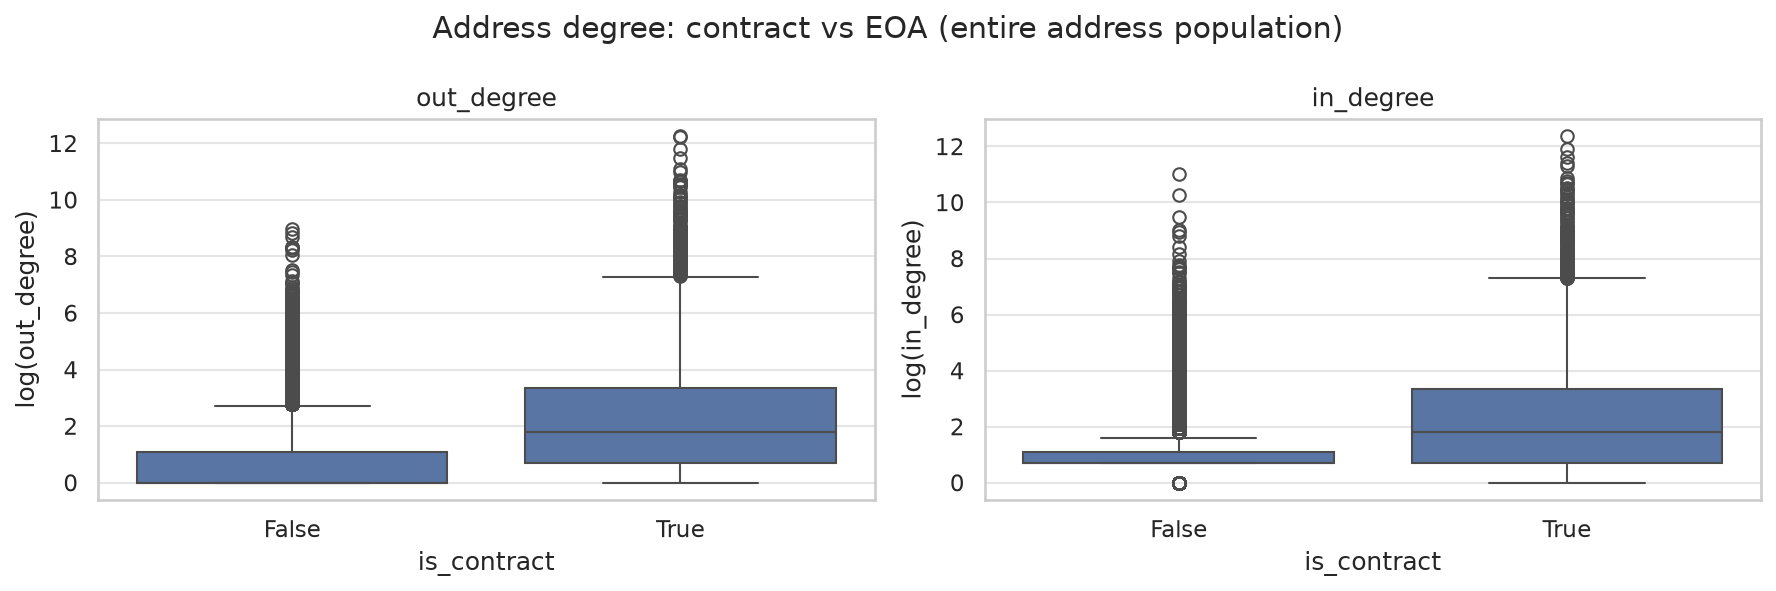

In [71]:
degree_by_contract = pd.DataFrame(
    {
        "out_degree": out_degree.reindex(contract_flags.index).fillna(0),
        "in_degree": in_degree.reindex(contract_flags.index).fillna(0),
        "is_contract": contract_flags.astype(str),
    }
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["out_degree", "in_degree"]):
    plot_df = degree_by_contract[[col, "is_contract"]].copy()
    plot_df[col] = np.log1p(plot_df[col])
    sns.boxplot(data=plot_df, x="is_contract", y=col, ax=ax)
    ax.set_title(col)
    ax.set_ylabel(f"log({col})")
fig.suptitle("Address degree: contract vs EOA (entire address population)")
plt.tight_layout()
plt.show()

***
The node degree distributions unequivocally expose the structural chasm between standard externally owned accounts and smart contracts. Contracts are characterized not only by a significantly higher median but also by a much broader interquartile range, confirming their systemic function as highly active transit hubs and distribution nodes within the network. Conversely, the connectivity profile of standard user accounts is heavily compressed at the very bottom of the logarithmic scale, with any intensive EOA activity manifesting strictly as rare, extreme outliers.
***

## Comparison: fraud vs clean-neighbor

A purely descriptive comparison of feature distributions between the two confirmed groups - addressing the question "what differentiates these two groups"

In [72]:
compare_cols = [
    "out_degree", "in_degree", "total_degree",
    "value_sent_zscore_mean", "value_sent_zscore_median",
    "value_received_zscore_mean", "value_received_zscore_median",
    "gas_price_mean", "gas_used_mean", "gas_fee_mean",
    "unique_tokens", "active_span_hours",
]

LOG_SCALE_COLS = {
    "out_degree", "in_degree", "total_degree",
    "gas_price_mean", "gas_used_mean", "gas_fee_mean",
    "unique_tokens", "active_span_hours",
}

fraud_vs_clean = address_features[address_features["label"].isin([0.0, 1.0])].copy()
fraud_vs_clean["label"] = fraud_vs_clean["label"].astype(str)

fraud_vs_clean[:5]

,out_degree,in_degree,value_sent_zscore_mean,value_sent_zscore_median,value_received_zscore_mean,value_received_zscore_median,gas_price_mean,gas_used_mean,gas_fee_mean,tokens_sent,tokens_received,active_span_hours,total_degree,unique_tokens,mint_count,burn_count,has_mint_activity,has_burn_activity,label,is_contract
address,,,,,,,,,,,,,,,,,,,,
0x0000000000bbf5c5fd284e657f01bd000933c96d,8.0,0.0,8.582726,8.479271,NaN,NaN,2.756291e+00,4.752699e+05,1.268155e-12,1.0,0.0,0.740000,8.0,1.0,0.0,0.0,False,False,0.0,True
0x00000011f84b9aa48e5f8aa8b9897600006289be,3171.0,2390.0,-0.346671,-0.414085,0.352911,-0.309830,5.083691e+09,2.603672e+05,2.546453e-03,1.0,1.0,333.873333,5561.0,2.0,0.0,0.0,False,False,0.0,True
0x00000047bb99ea4d791bb749d970de71ee0b1a34,2202.0,824.0,0.060854,-0.181270,-0.287811,-0.385265,1.887978e+09,2.939255e+05,5.682945e-04,159.0,6.0,330.790000,3026.0,165.0,0.0,2.0,False,True,0.0,True
0x00000688768803bbd44095770895ad27ad6b0d95,812.0,834.0,0.545156,0.477348,0.515870,0.522113,2.915723e+09,1.246358e+06,3.141508e-03,93.0,135.0,331.690000,1646.0,228.0,48.0,0.0,True,False,0.0,True
0x000313999b1c39fdd6dd213c78b5673ad896d42b,1.0,0.0,-0.414594,-0.414594,NaN,NaN,1.329436e+10,2.100000e+04,2.791815e-04,1.0,0.0,0.000000,1.0,1.0,0.0,0.0,False,False,0.0,False


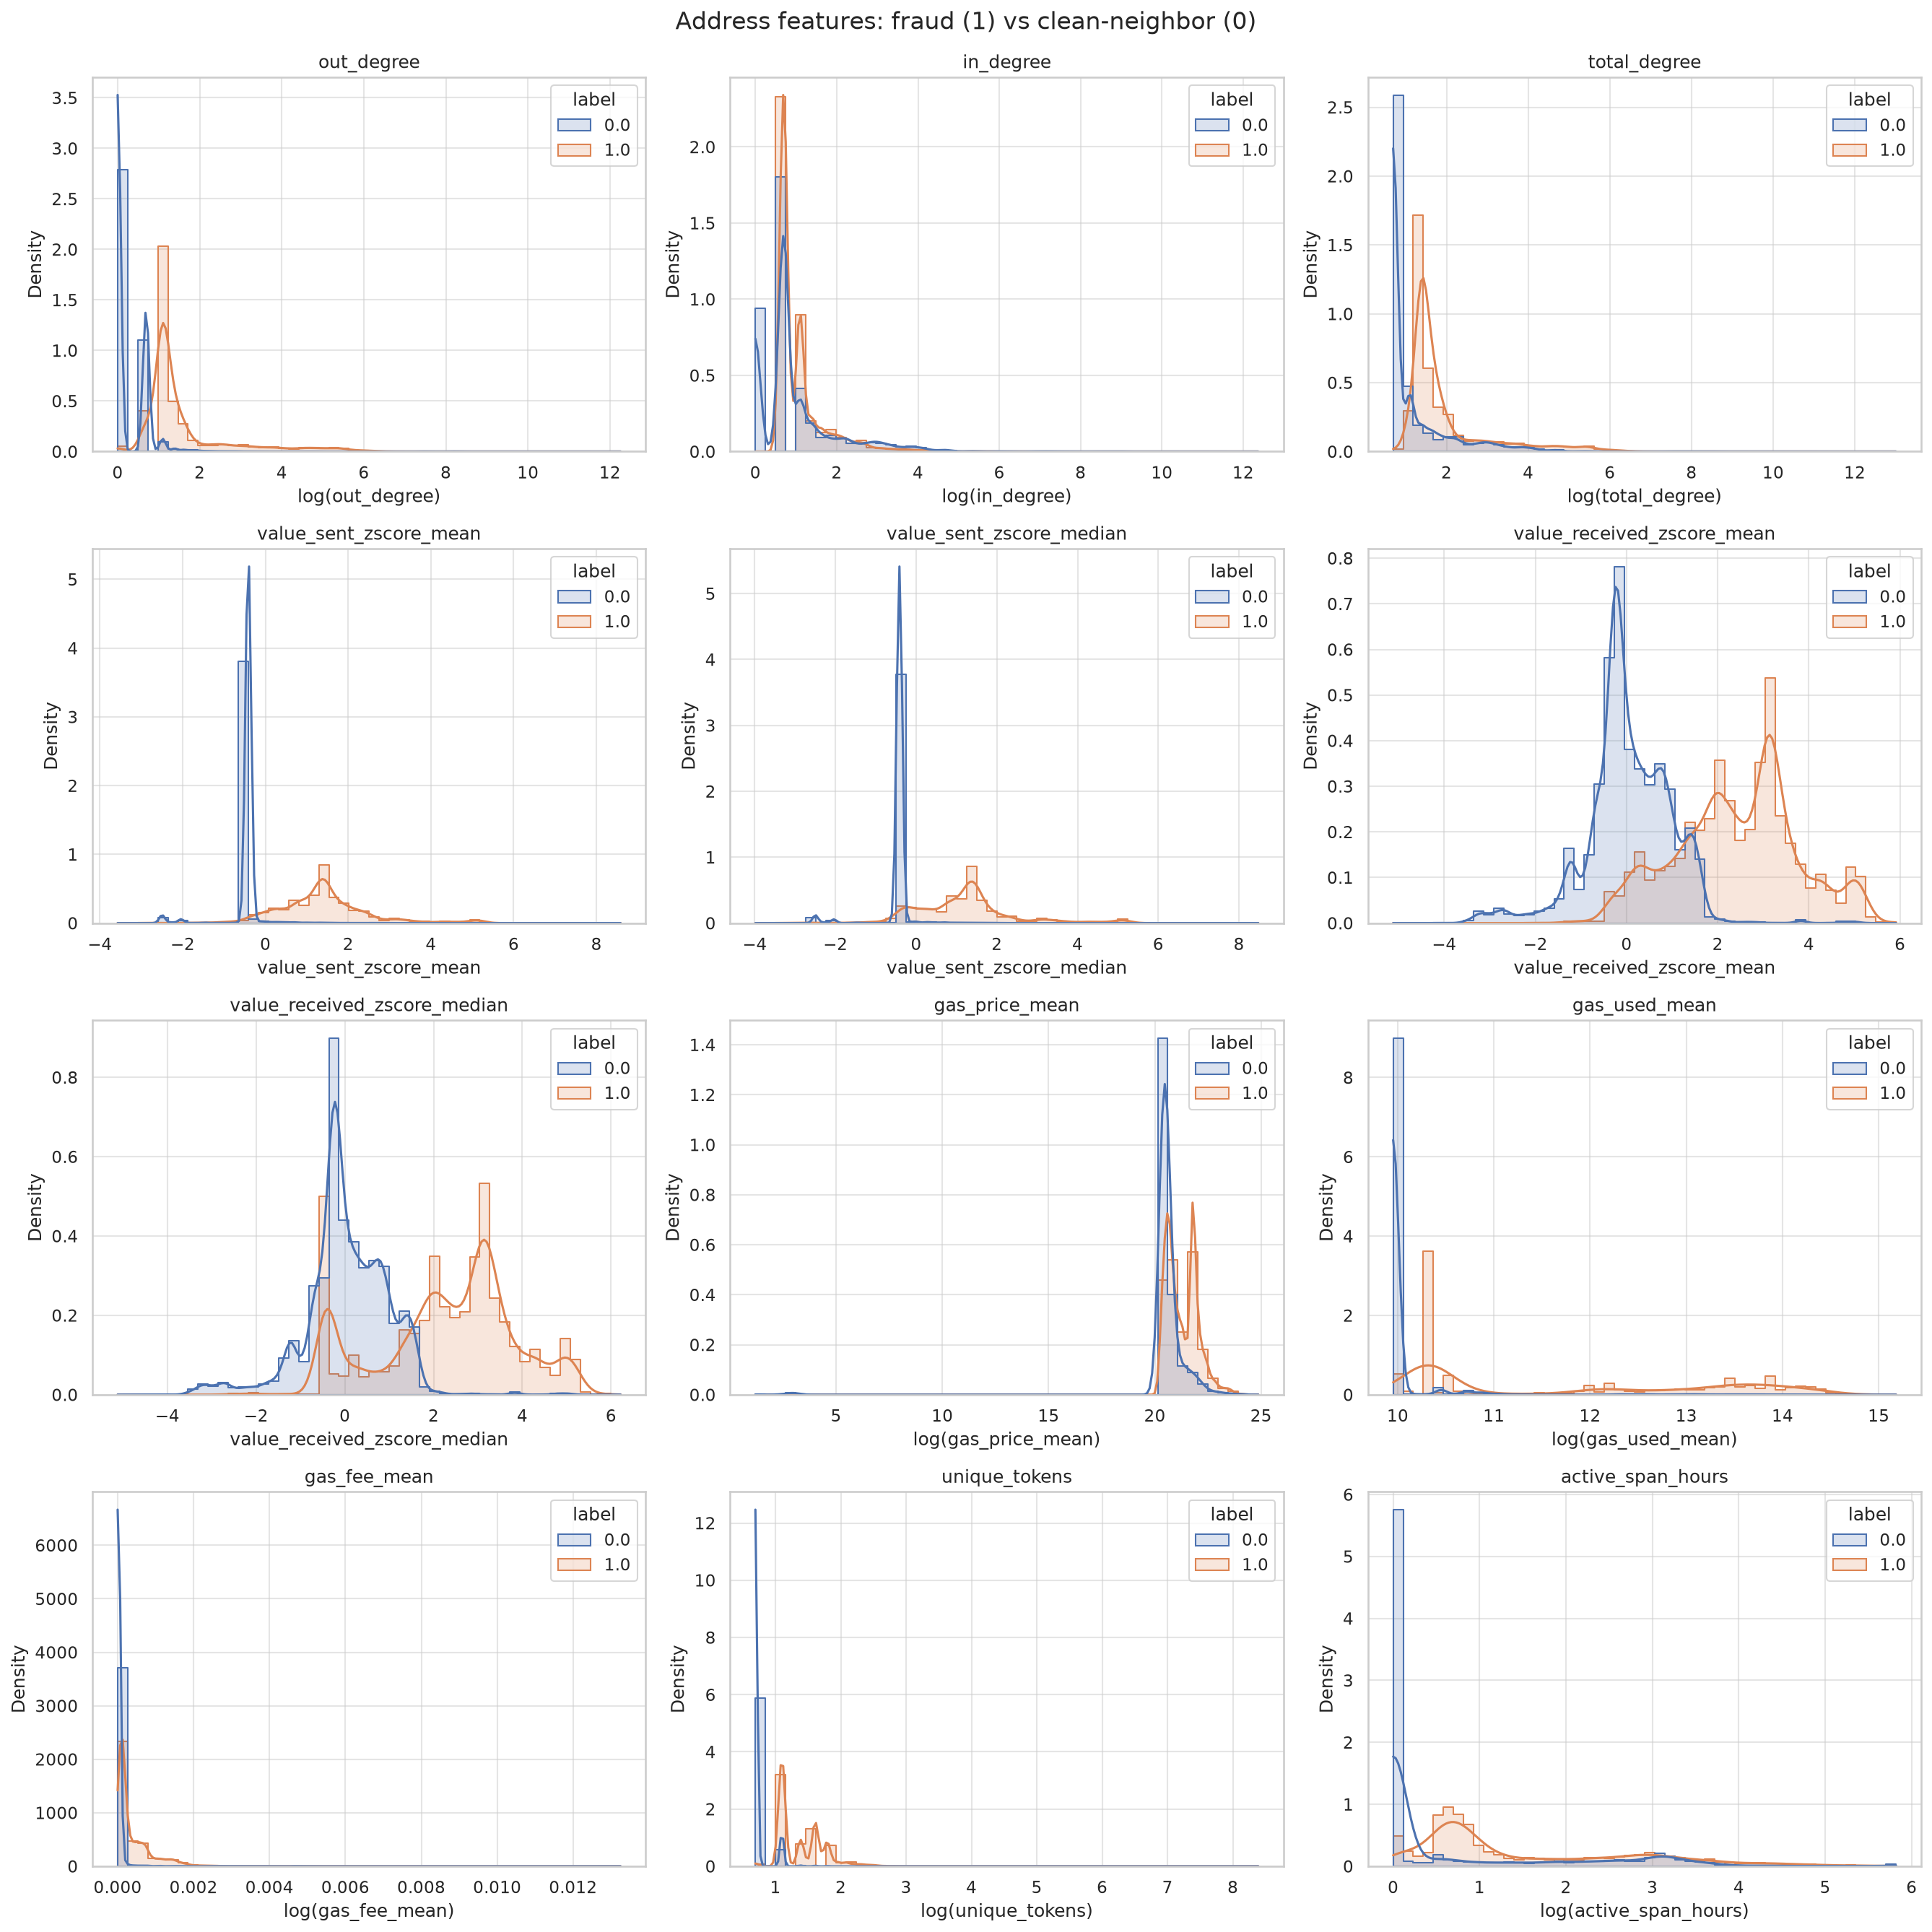

In [73]:
fig, axes = plt.subplots(4, 3, figsize=(18, 18))

for ax, col in zip(axes.flat, compare_cols):
    plot_values = fraud_vs_clean[["label", col]].dropna().copy()

    if col in LOG_SCALE_COLS:
        plot_values[col] = np.log1p(plot_values[col].clip(lower=0))
        xlabel = f"log({col})"
    else:
        xlabel = col

    sns.histplot(
        data=plot_values,
        x=col,
        hue="label",
        element="step",
        stat="density",
        common_norm=False,   # normalize each class separetely
        kde=True,
        bins=50,
        alpha=0.2,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

fig.suptitle("Address features: fraud (1) vs clean-neighbor (0)", fontsize=16, y=0.99)
fig.tight_layout()
plt.show()

***
The most prominent dividing line between the two groups is established by the token value features, where fraudulent addresses operate on volumes that drastically deviate from the asset-specific market norm. Unlike clean neighbors, whose transaction values cluster tightly around the baseline, flagged wallets systematically handle extreme positive deviations in both outgoing and incoming transfers.

A second critical structural divergence appears in the gas_used distribution, where the fraud cohort exhibits a distinct rightward shift towards heavier computational overheads. This topological signature demonstrates that malicious addresses frequently engage in complex, resource-intensive smart contract interactions typical of automated laundering pipelines, mixers, or decentralized exchange swaps, rather than executing simple native token transfers.

Furthermore the broader and more dispersed profiles observed in active_span_hours and unique_tokens expose the operational longevity and multi-asset routing behavior of the illicit entities. Rather than operating as volatile burner wallets, these nodes maintain activity across extended time windows and interact with a diverse portfolio of token contracts to obscure the fund-flow trail.
***

In [74]:
medians_by_label = fraud_vs_clean.groupby("label")[compare_cols].median()
median_diff = (medians_by_label.loc["1.0"] - medians_by_label.loc["0.0"]).rename(
    "fraud_minus_clean_median_diff"
)

feature_comparison_summary = pd.concat([medians_by_label.T, median_diff], axis=1)
feature_comparison_summary.sort_values("fraud_minus_clean_median_diff", key=np.abs, ascending=False)
feature_comparison_summary.style.format("{:.4f}")

,0.0,1.0,fraud_minus_clean_median_diff
out_degree,0.0000,2.0000,2.0000
in_degree,1.0000,1.0000,0.0000
total_degree,1.0000,3.0000,2.0000
value_sent_zscore_mean,-0.4146,1.3602,1.7748
value_sent_zscore_median,-0.4146,1.2371,1.6517
value_received_zscore_mean,-0.0568,2.4936,2.5504
value_received_zscore_median,-0.0568,2.5713,2.6282
gas_price_mean,780000000.0000,1588092551.0000,808092551.0000
gas_used_mean,21000.0000,39236.0000,18236.0000
gas_fee_mean,0.0000,0.0001,0.0001


In [75]:
contract_rate_by_label = fraud_vs_clean.groupby("label")["is_contract"].mean()
print("contract ratio per group:")
print(contract_rate_by_label)

contract ratio per group:
label
0.0    0.004822
1.0    0.001332
Name: is_contract, dtype: float64


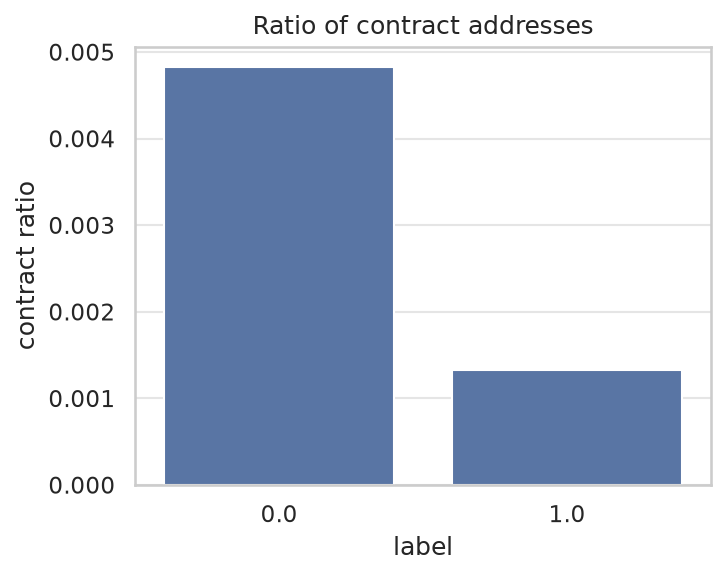

In [76]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=contract_rate_by_label.index.astype(str), y=contract_rate_by_label.values, ax=ax)
ax.set_xlabel("label")
ax.set_ylabel("contract ratio")
ax.set_title("Ratio of contract addresses")
plt.tight_layout()
plt.show()

# **Graph metrics analysis**

## Graph distance to the nearest confirmed fraud address

Multi-source BFS across the address graph from the set of confirmed fraud addresses to all other addresses. Does the "unknown" population sit topologically close to the fraud (suggesting undetected laundering hops) or far away?

In [77]:
from collections import defaultdict, deque

adjacency = defaultdict(set)
for a, b in zip(df_graph["from"].to_numpy(), df_graph["to"].to_numpy()):
    adjacency[a].add(b)
    adjacency[b].add(a)

fraud_addresses = set(unique_address_labels.loc[unique_address_labels["label"] == 1.0, "address"])

hop_distance = {addr: 0 for addr in fraud_addresses}
queue = deque(fraud_addresses)
while queue:
    current = queue.popleft()
    for neighbor in adjacency[current]:
        if neighbor not in hop_distance:
            hop_distance[neighbor] = hop_distance[current] + 1
            queue.append(neighbor)

print(f"nodes in the graph: {len(adjacency)} \n reachable from fraud: {len(hop_distance)}")

nodes in the graph: 57407 
 reachable from fraud: 57407


In [78]:
all_addresses = set(adjacency.keys())
labeled_addresses = set(unique_address_labels["address"])
unknown_addresses = all_addresses - labeled_addresses

unknown_hop_distance = pd.Series(
    {addr: hop_distance.get(addr, np.inf) for addr in unknown_addresses}, name="hop_distance"
)
unreachable_rate = (unknown_hop_distance == np.inf).mean()
print(f"unknown addresses: {len(unknown_hop_distance)}, unreachable from fraud: {unreachable_rate:.2%}")

hop_buckets = unknown_hop_distance.replace(np.inf, -1).apply(
    lambda h: "unreachable" if h == -1 else (str(int(h)) if h <= 3 else "4+")
)
hop_bucket_counts = hop_buckets.value_counts()
print(hop_bucket_counts)

unknown addresses: 11176, unreachable from fraud: 0.00%
hop_distance
2     10838
3       337
4+        1
Name: count, dtype: int64


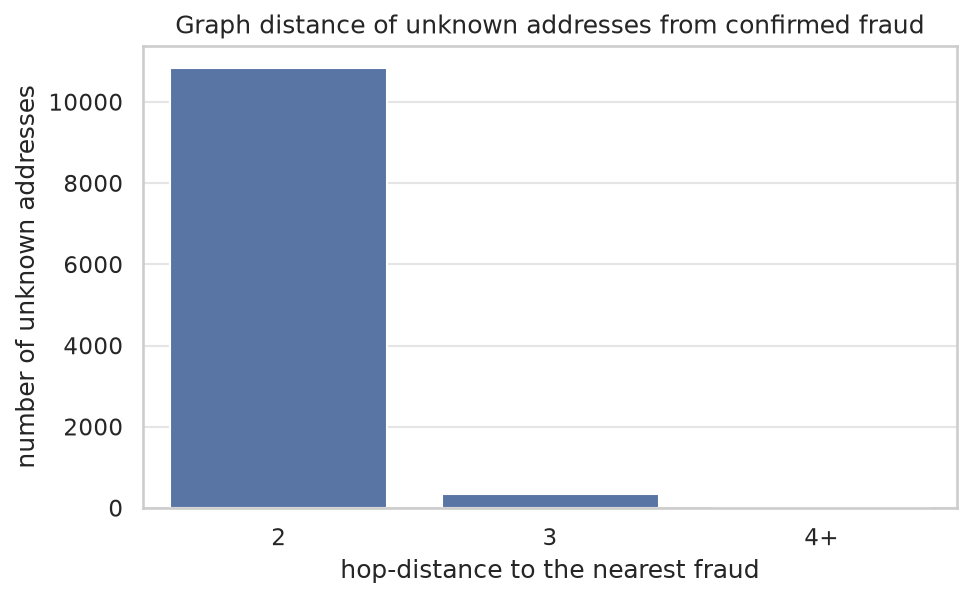

In [79]:
order = [b for b in ["1", "2", "3", "4+"] if b in hop_bucket_counts.index]
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=order, y=hop_bucket_counts.reindex(order).values, ax=ax)
ax.set_xlabel("hop-distance to the nearest fraud")
ax.set_ylabel("number of unknown addresses")
ax.set_title("Graph distance of unknown addresses from confirmed fraud")
plt.show()

## Contract ratio among unknown by hop-distance

Question: are the unknown addresses situated close to the fraud primarily contracts (routers/pools acting as pass-through hops), or EOAs (potential downstream fund holders)?

contract ratio among 'unknown' per hop-distance:
hop_bucket
2     0.535154
3     0.869436
4+    1.000000
Name: is_contract, dtype: float64


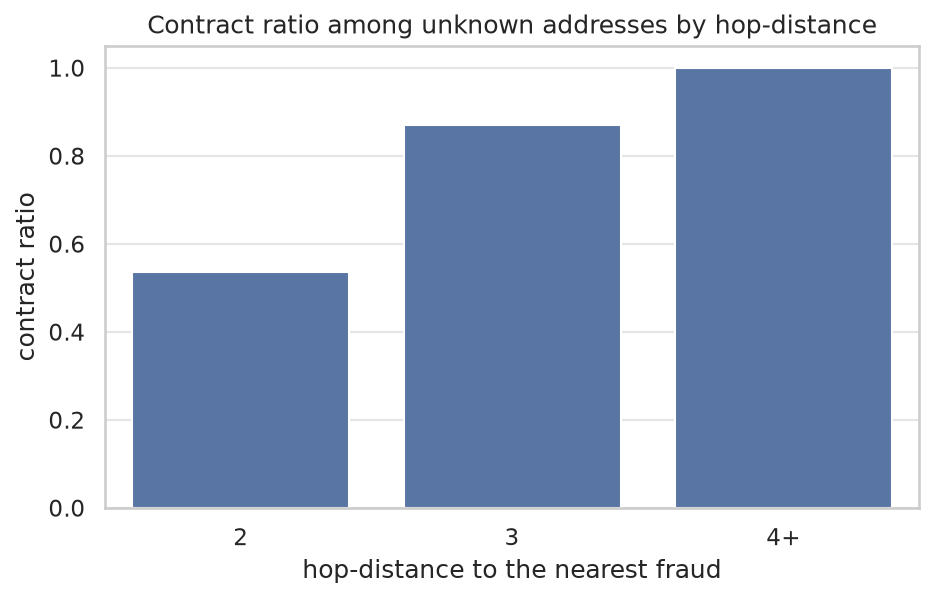

In [80]:
unknown_contract_flags = contract_flags.reindex(unknown_hop_distance.index)
contract_rate_by_hop_bucket = (
    pd.DataFrame({"hop_bucket": hop_buckets, "is_contract": unknown_contract_flags})
    .groupby("hop_bucket")["is_contract"]
    .mean()
    .reindex(order)
)
print("contract ratio among 'unknown' per hop-distance:")
print(contract_rate_by_hop_bucket)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=contract_rate_by_hop_bucket.index, y=contract_rate_by_hop_bucket.values, ax=ax)
ax.set_xlabel("hop-distance to the nearest fraud")
ax.set_ylabel("contract ratio")
ax.set_title("Contract ratio among unknown addresses by hop-distance")
plt.show()

***
The topological analysis of the transaction graph reveals complete network connectivity with all nodes remaining directly reachable from confirmed fraud addresses. The hop-distance distribution for unknown addresses indicates that the vast majority of the population concentrates at a distance of just 2 hops. Furthermore, the contract ratio as a function of hop distance exhibits a distinct upward trend-ranging from roughly 54% at 2 hops to 100% at the furthest distances-proving that advanced smart contracts, routing protocols, and liquidity pools form a structural barrier and buffering layer separating the fraud source from the wider network
***


## Methodological caveats

- **Label sparsity**: from_label/to_label are available only for addresses associated with known/flagged actors - not for the general address population.
- **Single event**: the entire dataset concerns one incident (the ByBit hack) - it is not a representative sample of general Ethereum traffic; a model trained on it will absorb the specific quirks of this event.
- **Narrow time window**: a single continuous 14-day span, lacking any seasonal signal.
- **Systematic bias of the negative (0) label**: throughout the dataset, label=0 occurs exclusively as a direct counterparty to a confirmed label=1 - never on its own. "Clean" addresses here are strictly the immediate neighbors of the hacker (likely exchanges/bridges), rather than a random sample of the general address population.
- **Zero/burn address acting as an artificial hub**: prior to being excluded from the graph, the zero address itself connected 17 fraud addresses and possessed a degree of 3017 - without it, 1381 out of 12558 (11%) unknown addresses become unreachable instead of being at hop=2/3. Part of the previous "entire graph is within 3 hops of fraud" finding was an artifact of this hub, not genuine proximity.
- **Token symbol spoofing**: 571 out of 5847 tokenSymbol map to more than one contractAddress - eg rows labeled USDT exhibit tokenDecimal e {6, 18, 9} with max value reaching 81 million. This is a strong indicator of tokens spoofing known names.
- **Gas deduplicated by transaction**: gas is an attribute of the hash, not a transfer - duplicated across each of the transfers within a single transaction. Per-address and dataset-wide gas features are calculated after deduplicating by hash.